# Compute a covariance analogous to DES cluster 6x2pt + N

A covariance matrix $C_{ij}=\langle(d_i-\bar d_i)(d_j-\bar d_j)\rangle$ describes how the entries of a measured data vector $d$ scatter around their mean $\bar d$, and how strongly two entries scatter together; a Gaussian likelihood uses its inverse. This notebook computes a forecast covariance for the joint cluster and galaxy data vector of this project and keeps three physical components separate:

- **Gaussian (G)**: the covariance the fields would have if they were Gaussian. It is built from products of two-point spectra and noise: shape noise of the source galaxies, shot noise of galaxies and clusters, and Poisson noise of the counts.
- **Super-sample covariance (SSC)**: density modes larger than the survey footprint shift all measurements together. A footprint inside a large overdense region, for example, contains more clusters and shows stronger clustering everywhere.
- **Connected non-Gaussian covariance (cNG)**: the connected four-point function (the trispectrum) of the density field inside the footprint, produced by nonlinear structure formation.

### The 2,812-entry joint layout

The matrix has the layout of the likelihood's data vector: 2,800 two-point entries in rows of 20 angular bins, and 12 cluster counts, in the order ss, gs, gg, cg, N, cc, cs.

| Block | Measurement | Entries |
| --- | --- | --- |
| `ss` | cosmic shear $\xi_+$ and $\xi_-$, 10 source-bin pairs | 400 |
| `gs` | galaxy–galaxy lensing $\gamma_t$, 6 lens × 4 source bins | 480 |
| `gg` | galaxy clustering $w$, 6 lens bins | 120 |
| `cg` | cluster–galaxy clustering, 12 cluster samples | 240 |
| `N` | cluster counts, 3 redshift × 4 richness bins | 12 |
| `cc` | cluster clustering, 10 richness pairs in each of 3 redshift bins | 600 |
| `cs` | cluster lensing $\Sigma=Y\gamma_t$, 3 redshift × 4 source × 4 richness rows | 960 |

Clusters are grouped in three observed-redshift bins (edges 0.2, 0.4, 0.55, 0.65) and four bins of **richness** $\lambda$, the number of red-sequence member galaxies, which serves as a noisy proxy for the halo mass (edges 20, 30, 45, 60, 500). Richness is the faster index inside each redshift bin. The counts are **absolute numbers** of clusters in the 4,143 deg² footprint, not density contrasts: their Gaussian term is Poisson noise, with a variance equal to the mean count.

In the plot labels, `s` denotes source shear, `g` galaxy density, `c` cluster density and `N` absolute counts. The `ss` block contains both $\xi_+$ and $\xi_-$; $c\Sigma$ denotes localized cluster lensing.

### The Y localization and its null rows

In $\Sigma=Y\gamma_t$, $Y$ is a fixed matrix acting on the angular bins of the tangential shear. It produces the localized statistic $Y(R)=\Sigma(R)-\Sigma(R_{\max})$: the projected surface mass density at radius $R$ minus its value at the outermost radius $R_{\max}$, in units of the critical surface density, which removes the dependence on the mass inside $R$. If the mean changes as $y=Ax$, the covariance changes as $C_y=AC_xA^{\mathsf T}$, so the forecast applies $Y$ to both axes of G, SSC and cNG, including the count–lensing cross blocks, before any cut. At $R=R_{\max}$ the statistic is identically zero: the last angular bin of each of the 48 cluster-lensing rows has an exactly zero row and column. `valid_indices` lists every entry except these 48 defined null rows. The 6×2pt + N mask removes them as well as the physical scale cuts.

### What the forecast includes and omits

- Massless neutrinos, Limber spectra, linear galaxy bias, zero intrinsic alignment (IA), magnification and redshift-space distortions, and a spherical-cap footprint. Non-Limber and IA terms of the cluster fields are not implemented; the separate galaxy/shear adapter supports Gaussian non-Limber and NLA/TATT.
- The fiducial cosmology, printed below, is the covariance example's massless-neutrino point, not Table I of the paper used for the synthetic data vector. The clusters use the Table I mass–richness relation, abundance-weighted radial windows and no selection bias.
- SSC uses the isotropic halo-model response of the matter power spectrum, and all counts and two-point functions respond to the same long-wavelength modes.
- cNG uses the **biased-tracer approximation**: each galaxy or cluster density leg of the four-point function becomes its linear bias times the matter density, so cNG is a product of biases times the halo-model matter trispectrum. Massive-neutrino non-Gaussian terms are not implemented.
- The counts correlate with the two-point functions **through SSC only**. Two terms are omitted: the selected-cluster one-halo corrections to cNG, and the non-SSC count–spectrum covariance, which arises because the counted halos also contribute to the measured spectra. The result archives these omissions in `settings["omitted_terms"]`.

The supplied likelihood matrix is synthetic: Gaussian two-point covariance, Poisson plus sample-variance counts and zero count–spectrum crosses, computed with the data-vector model (Table I cosmology with a massive neutrino, selection bias, cluster magnification). This notebook reads it and applies **the same likelihood mask** to both matrices. Differences from it therefore include deliberate model differences; matching the measurement layout does not establish physical or numerical equivalence. No likelihood data file is overwritten and no covariance is installed in C.

| Measurement choice | Value |
| --- | --- |
| Dataset | [data/des_cluster_y6_6x2ptN.dataset](data/des_cluster_y6_6x2ptN.dataset) |
| Lens / source bins | 6 / 4 |
| Bins per two-point observable | 20, 2.5–250 arcmin |
| Generated entries before cuts | 2,812 |
| Entries after the selected likelihood mask | 1,429 |

The [covariance guide](covariance/README.md) explains survey inputs and how to start Jupyter. The decomposition follows [Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and [Takada & Hu](https://arxiv.org/abs/1302.6994).
Covariance generation is excluded from the default build. Follow the [project build steps](README.md#computing_covariances): after activating Cocoa, unset `IGNORE_COSMOLIKE_DES_CLUSTER_COVARIANCE` and recompile this project. Restart the notebook kernel after rebuilding.


In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/des_cluster"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_des_cluster_interface as ci
import des_cluster_joint_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.likelihood import (
    read_likelihood_covariance,
    select_likelihood_entries,
)
from cosmolike_notebook_utils.covariance.forecast_cluster import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

## Choose the measurement and numerical settings

The default run computes the joint angular (real-space) measurement once, at accuracy boost 1. Set `boosts = [1, 2]` to add the numerical comparison below. Keep `spaces = ['real']`: the joint cluster generator computes angular correlation functions only, and the loop below stops with an error for any other space. The galaxy/shear Fourier companion is the optional last section.

`accuracy_boost` multiplies the internal interpolation refinements and multipole cutoffs in [covariance/default.yaml](covariance/default.yaml). The default power tables have 11,993 wavenumber samples; boost 2 uses 23,985 while retaining all original nodes. The loop below reinitializes these tables for each boost. `integration_accuracy` independently selects 96, 128, 256, 512 or 1,024 precomputed GSL nodes per panel at levels 0–4. Keep the scientific bins, cosmology and CAMB inputs fixed when refining.

The next cell prints the physical inputs of the forecast: the survey area in deg², the galaxy and source densities per arcmin², the shape-noise dispersion per ellipticity component, the linear galaxy biases, the cosmology and the base accuracy controls. `survey.initialize` then runs CAMB and installs the cosmology, the redshift distributions and the cluster selection (richness bins, redshift kernels, mass–richness relation) in the interface, without reading the likelihood's data, mask or covariance.

The defaults remain **candidate accuracy settings**. Positive definiteness and a small change in diagonal errors do not establish convergence of all covariance modes or of Fisher parameter errors. A comparison with the supplied matrix also mixes physical choices with numerical differences.

In [2]:
boosts = [1]
spaces = ['real']
settings = survey.configuration(accuracy_boost=boosts[0])
dataset = project/"data/des_cluster_y6_6x2ptN.dataset"

# These are physical assumptions, not inferred from normalized n(z) columns.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
):
    print(key, settings[key])

camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)


def progress(stage, elapsed):
    """Report completed stages of this calculation, in seconds."""
    print(f"{elapsed:8.2f} s  {stage}")

area_deg2 4143.0
lens_density_arcmin2 [0.138, 0.1016, 0.1071, 0.1381, 0.1054, 0.1045]
source_density_arcmin2 [2.1402, 2.14455, 2.1518, 2.11845]
sigma_e_component [0.27199993709190445, 0.27199993709190445, 0.27199993709190445, 0.27199993709190445]
bias [1.42, 1.66, 1.7, 1.62, 1.78, 1.75]
cosmology {'omegam': 0.3, 'omegab': 0.05, 'H0': 70.0, 'ns': 0.965, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}


## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. Its four density factors can live in one,
two, three or four halos. The halo model separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.

For the joint cluster example, this figure shows the matter trispectrum
used in the biased-tracer cNG approximation. It does not represent a
selected-cluster trispectrum or add the missing cluster one-halo terms
and non-SSC count–spectrum correlations.


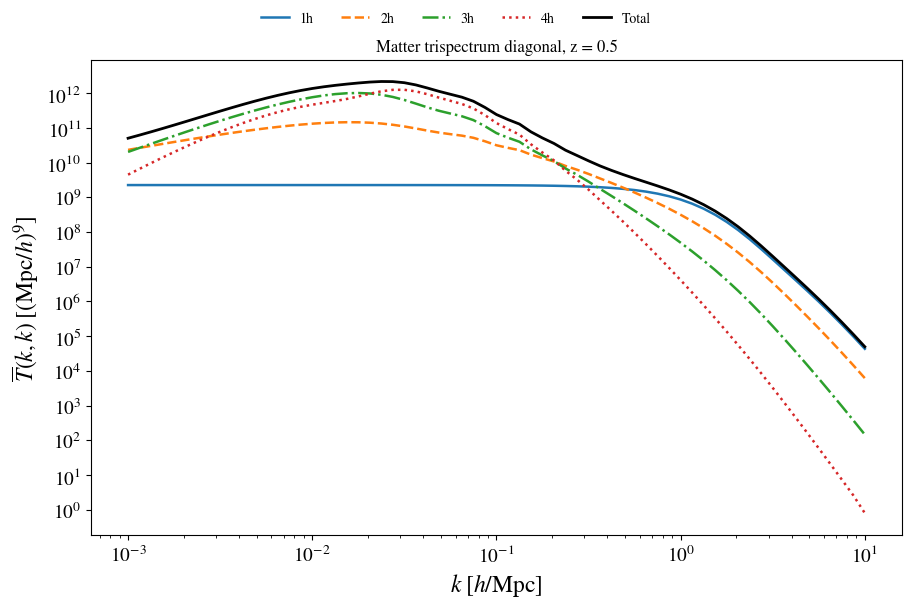

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute G, SSC, cNG and their sum

`survey.compute` assembles the full 2,812 × 2,812 matrix in five stages, which `progress` reports with elapsed seconds:

1. **All-pairs Limber spectra.** The covariance of measured spectra $AB$ and $CD$ needs the spectra $AC$, $BD$, $AD$ and $BC$, including cross-bin pairs absent from the data vector, so every pair of galaxy, cluster and source fields is computed.
2. **Gaussian covariance and means.** Bin-averaged angular transforms give G for every pair of rows, with shot noise $1/\bar n$ for galaxies and clusters ($\bar n$ per steradian), shape noise $\sigma_e^2/\bar n$ for sources and Poisson variance for the counts.
3. **Shared halo tables.** The halo-model matter response and trispectrum depend on distance and wavenumbers, not on which catalog is measured, so they are computed once and shared by every block.
4. **SSC and cNG.** One set of long-mode responses per radial shell correlates all counts and two-point functions. Density contrasts subtract the response of their observed catalog mean; absolute counts do not. cNG multiplies the matter trispectrum by one linear bias per density leg, and its count rows are zero.
5. **Localization.** $Y$ acts on both axes of G, SSC and cNG; the total is their sum.

Angular bins are consecutive within each row. The loop changes only numerical resolution and stores all physical components at each requested boost. `forecast`, the result at the highest boost, is a dictionary with the matrices `gaussian`, `ssc`, `cng` and `total`, the layout arrays (`rows`, `two_point_positions`, `count_positions`, `cluster_lensing_positions`, `valid_indices`), the mean signals `signal` and `mean_counts`, and the resolved `settings`.

In [4]:
# Each space uses its own projection. Changing the boost refines tables
# while preserving cosmology, observable ordering and measured bins.
results = {}
for space in spaces:
    if space not in ['real']:
        raise ValueError("Choose a measurement space supported by this adapter")
    results[space] = {}
    for boost in boosts:
        # dict(settings) is a shallow copy, so update() changes the copy only;
        # ** passes each base control of default.yaml as a named argument.
        refined = dict(settings)
        refined.update(cov.covariance_accuracy(
            accuracy_boost=boost, **settings["accuracy_parameters"],
        ))
        # Reinstall the power tables at this boost, so their k grid
        # is refined along with the covariance integration tables.
        camb_tables = survey.initialize(interface=ci, settings=refined)
        ci.set_omp_threads(n=8)
        print(space, "accuracy boost", boost)
        results[space][boost] = survey.compute(interface=ci, settings=refined, progress=progress)

# The highest boost is the reference of the comparisons below.
native_space = 'real'
forecast = results[native_space][boosts[-1]]
print("Full covariance shape:", forecast["total"].shape)

real accuracy boost 1


   23.81 s  all_pairs_limber_spectra


   35.43 s  gaussian_and_mean


   35.96 s  Matter shell 1/1056


   42.87 s  Matter shell 33/1056


...

  251.56 s  Matter shell 993/1056


  258.88 s  Matter shell 1025/1056


  266.21 s  shared_halo_tables


  266.89 s  joint_ssc_and_connected


  267.26 s  localization
  267.26 s  total
Full covariance shape: (2812, 2812)


## Positivity before and after removing the Y null rows

A covariance must give a nonnegative variance to every linear combination of measurements, $v^{\mathsf T}Cv\ge0$, and an invertible covariance must be **positive definite**: all its eigenvalues are positive. `cov.covariance_modes` tests this without changing the matrix. It divides each entry by $\sqrt{C_{ii}C_{jj}}$ and computes the eigenvalues of the resulting correlation matrix. This change of units cannot change the sign of any mode, and it puts the counts (variances of thousands) and the shear correlations (variances many orders of magnitude smaller) on one scale. The raw eigenvalues are returned too. They span so many decades that floating-point rounding, of order $10^{-16}$ times the largest eigenvalue, produces tiny negative raw values with no physical meaning.

The full 2,812-entry total contains the 48 defined Y null rows, whose variance is exactly zero; its correlation matrix is undefined, so the test reports it as not positive definite. `forecast["valid_indices"]` removes only those rows: it changes the definition of the measured vector and is not a scale cut. If the remaining 2,764-entry matrix is positive definite, every likelihood selection from it is positive definite as well, because a principal submatrix of a positive-definite matrix is positive definite. The minimum correlation eigenvalue can be small: each localized value integrates the profile from its own radius out to $R_{\max}$, so neighboring bins share most of their integrand and are strongly correlated.

In [5]:
null_rows = forecast["cluster_lensing_positions"][:, -1]  # last bin of each row
zero_variances = np.count_nonzero(np.diag(forecast["total"]) == 0.0)
print("Y null rows:", len(null_rows), "; zero variances in the total:", zero_variances)
# np.ix_(valid, valid) selects the same entries on both covariance axes.
valid = forecast["valid_indices"]
cases = {"All entries": forecast["total"],
         "valid_indices": forecast["total"][np.ix_(valid, valid)]}
for name, matrix in cases.items():
    modes = cov.covariance_modes(matrix=matrix)
    eigenvalues = modes["eigenvalues"]
    print(f"{name}: {len(matrix)} entries;",
          f"positive definite: {modes['positive_definite']};",
          f"raw eigenvalues from {eigenvalues[0]:.2e} to {eigenvalues[-1]:.2e}")
    if modes["correlation_eigenvalues"] is not None:
        print("  minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

Y null rows: 48 ; zero variances in the total: 48


All entries: 2812 entries; positive definite: False; raw eigenvalues from -2.90e-12 to 6.77e+03


valid_indices: 2764 entries; positive definite: True; raw eigenvalues from -3.76e-12 to 6.77e+03
  minimum correlation eigenvalue: 1.7820514061674378e-05


## Inspect the count block: Poisson noise and SSC

The 12 counts sit between the `cg` and `cc` blocks, at entries 1,240–1,251 (`forecast["count_positions"]`), ordered by cluster redshift bin and, inside it, by richness. Their covariance has two parts in this forecast.

- **Poisson noise.** Each cluster falls in exactly one (redshift, richness) bin, so for a fixed density field the counts are independent Poisson numbers: G is diagonal, with variance equal to the mean count $\bar N_i$.
- **SSC.** A density mode larger than the survey raises or lowers the abundance of clusters in all bins together. For bins $i$ and $j$ the SSC term is $\int d\chi\,\Phi_i\Phi_j\,\sigma_b^2$, where $\Phi_i$ is the response of the counts per unit comoving distance to a background overdensity $\delta_b$. $\sigma_b^2$ has units of length: averaged over the footprint and over a shell of width $\Delta\chi$, $\delta_b$ has the variance $\sigma_b^2/\Delta\chi$.

Their ratio is roughly $b_i^2\,\bar N_i\,\sigma_V^2$, with $b_i$ the bias of the clusters in bin $i$ and $\sigma_V^2$ the variance of the mean matter density in the survey volume of the bin. SSC therefore matters most for the most populated bins and for the most biased, richest clusters ([Hu & Kravtsov 2003](https://arxiv.org/abs/astro-ph/0203169)). The cNG term has no count rows here, so every correlation between two different count bins comes from SSC; bins at different redshifts correlate only where their true-redshift distributions overlap.

In [6]:
# Counts in the joint vector: cluster redshift bin outer, richness bin inner.
counts = forecast["count_positions"]
mean_counts = forecast["mean_counts"]
poisson = np.diag(forecast["gaussian"])[counts]
ssc_counts = np.diag(forecast["ssc"])[counts]
print("Gaussian count variance equals the mean count:",
      np.array_equal(poisson, mean_counts))
richness_edges = settings["cluster_richness_edges"]
nrichness = len(richness_edges) - 1
for index in range(len(counts)):
    redshift_bin = index // nrichness
    richness_bin = index % nrichness
    print(f"z bin {redshift_bin + 1}, lambda in [{richness_edges[richness_bin]:g}, "
          f"{richness_edges[richness_bin + 1]:g}): N = {mean_counts[index]:7.1f}, "
          f"SSC/Poisson = {ssc_counts[index]/poisson[index]:.3f}")

Gaussian count variance equals the mean count: True
z bin 1, lambda in [20, 30): N =  3815.6, SSC/Poisson = 0.591
z bin 1, lambda in [30, 45): N =  1714.3, SSC/Poisson = 0.394
z bin 1, lambda in [45, 60): N =   553.2, SSC/Poisson = 0.184
z bin 1, lambda in [60, 500): N =   453.4, SSC/Poisson = 0.259
z bin 2, lambda in [20, 30): N =  4634.3, SSC/Poisson = 0.400
z bin 2, lambda in [30, 45): N =  1919.1, SSC/Poisson = 0.248
z bin 2, lambda in [45, 60): N =   566.4, SSC/Poisson = 0.106
z bin 2, lambda in [60, 500): N =   400.0, SSC/Poisson = 0.124
z bin 3, lambda in [20, 30): N =  3485.0, SSC/Poisson = 0.295
z bin 3, lambda in [30, 45): N =  1348.2, SSC/Poisson = 0.172
z bin 3, lambda in [45, 60): N =   369.2, SSC/Poisson = 0.069
z bin 3, lambda in [60, 500): N =   232.1, SSC/Poisson = 0.070


In [7]:
# Different count bins correlate only through SSC in this forecast.
count_block = np.ix_(counts, counts)
count_total = forecast["total"][count_block]
# ~ negates the boolean identity matrix: True off the diagonal only.
off_diagonal = ~np.eye(len(counts), dtype=bool)
off_diagonal_ssc = forecast["ssc"][count_block][off_diagonal]
print("Off-diagonal count covariance equals SSC:",
      np.array_equal(count_total[off_diagonal], off_diagonal_ssc))
sigma_counts = np.sqrt(np.diag(count_total))
print("Count correlation matrix, rows and columns ordered as in the table above:")
print(np.round(count_total/np.outer(sigma_counts, sigma_counts), decimals=2))

Off-diagonal count covariance equals SSC: True
Count correlation matrix, rows and columns ordered as in the table above:
[[1.   0.32 0.24 0.27 0.01 0.01 0.01 0.01 0.   0.   0.   0.  ]
 [0.32 1.   0.21 0.24 0.01 0.01 0.01 0.01 0.   0.   0.   0.  ]
 [0.24 0.21 1.   0.18 0.01 0.01 0.   0.   0.   0.   0.   0.  ]
 [0.27 0.24 0.18 1.   0.01 0.01 0.   0.   0.   0.   0.   0.  ]
 [0.01 0.01 0.01 0.01 1.   0.24 0.17 0.18 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.01 0.24 1.   0.14 0.15 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.   0.   0.17 0.14 1.   0.1  0.01 0.01 0.   0.  ]
 [0.01 0.01 0.   0.   0.18 0.15 0.1  1.   0.01 0.01 0.   0.  ]
 [0.   0.   0.   0.   0.01 0.01 0.01 0.01 1.   0.18 0.12 0.12]
 [0.   0.   0.   0.   0.01 0.01 0.01 0.01 0.18 1.   0.1  0.1 ]
 [0.   0.   0.   0.   0.01 0.01 0.   0.   0.12 0.1  1.   0.06]
 [0.   0.   0.   0.   0.01 0.01 0.   0.   0.12 0.1  0.06 1.  ]]


## Where do SSC and cNG raise the errors?

`pcov.plot_covariance_diagonal` draws, for consecutive groups of angular bins, either the standard deviations $\sigma_i=\sqrt{C_{ii}}$ or, with a reference matrix, their percent change $100\,(\sigma_i/\sigma_i^{\rm ref}-1)$. With G as the reference and the total as the curve, it shows how much SSC and cNG add to the error of each angular bin before the likelihood cuts. The three panels compare clustering rows of increasingly rare tracers: lens-galaxy bin 1, the cross-correlation of the first cluster sample (redshift bin 1, richness bin 1) with lens bin 1, and the auto-correlation of that cluster sample. The two-point rows of `forecast["rows"]` run ss (20 rows: 10 source pairs for each of $\xi_\pm$), gs (24), gg (6), cg (12), cc (30) and cs (48), so rows 44, 50 and 62 open the gg, cg and cc blocks.

G contains the shot noise $1/\bar n$, which is large for rare tracers. SSC and cNG therefore change the diagonal errors of the cluster rows much less than those of the galaxy row. The largest changes occur at small angles, many of which the likelihood mask removes (it keeps $R>8$ Mpc/$h$ for galaxy clustering). A slightly negative percentage means that the connected term is negative there: individual components may be negative, only the total must be positive definite. For the counts SSC is a larger fraction, as the previous section shows, and the non-Gaussian terms also act through the correlations between bins shown in the component maps below.

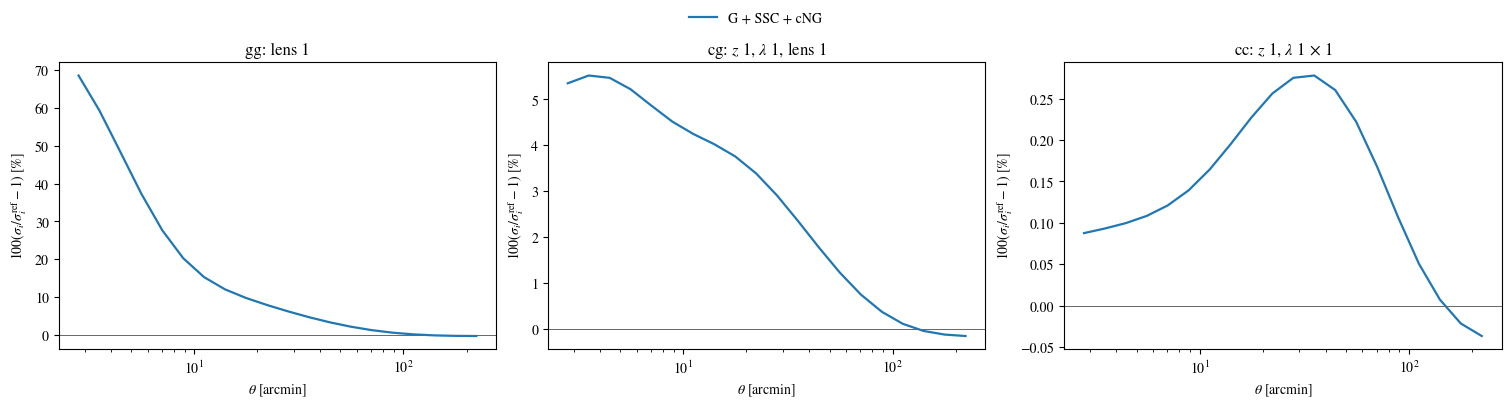

In [8]:
# One row of 20 angular entries per two-point row (-1 lets NumPy infer the 20).
row_entries = forecast["two_point_positions"].reshape(len(forecast["rows"]), -1)
# Rows 44, 50 and 62 open the gg, cg and cc blocks (see the text above).
panels = {
    "gg: lens 1": 44,
    r"cg: $z$ 1, $\lambda$ 1, lens 1": 50,
    r"cc: $z$ 1, $\lambda$ 1 $\times$ 1": 62,
}
entries = np.concatenate([row_entries[row] for row in panels.values()])
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"],
    covariances={"G + SSC + cNG": forecast["total"][np.ix_(entries, entries)]},
    panel_labels=list(panels.keys()),
    covariance_ref=forecast["gaussian"][np.ix_(entries, entries)],
)

## Apply the project's likelihood cuts

The supplied mask selects measurements, so the same selection must act on both axes of G, SSC, cNG and their sum. `read_likelihood_covariance` reads the dataset's total covariance (here `des_cluster_y6_cov.npy`, the packed upper triangle of the synthetic matrix) and its mask, and `select_likelihood_entries` applies the mask to every matrix. It refuses a mask that keeps a defined Y null row. The saved `indices` preserve the original file positions after compaction. Probe labels refer to contiguous groups in the uncut likelihood vector, including any measured-pair exclusions. For text covariance files with separate Gaussian and non-Gaussian columns the reader adds the columns; it never splits a combined column into SSC and cNG.

The supplied total appears in the upper triangle of the correlation plot and the newly computed total in the lower triangle. Each uses its own diagonal for the correlation normalization $C_{ij}/\sqrt{C_{ii}C_{jj}}$; differences here are **not** a numerical convergence test. The component maps divide G, SSC and cNG by the same total diagonal, so each map shows how much of every correlation that component supplies. The last lines test the positivity of both selected totals from their correlation eigenvalues.

Supplied file size: 2812
Retained comparison size: 1429
Mask: des_cluster_y6_6x2ptN.mask


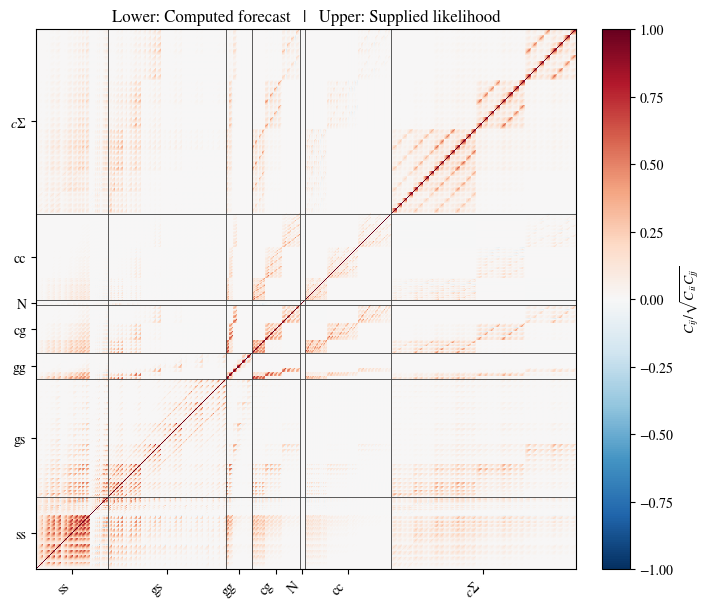

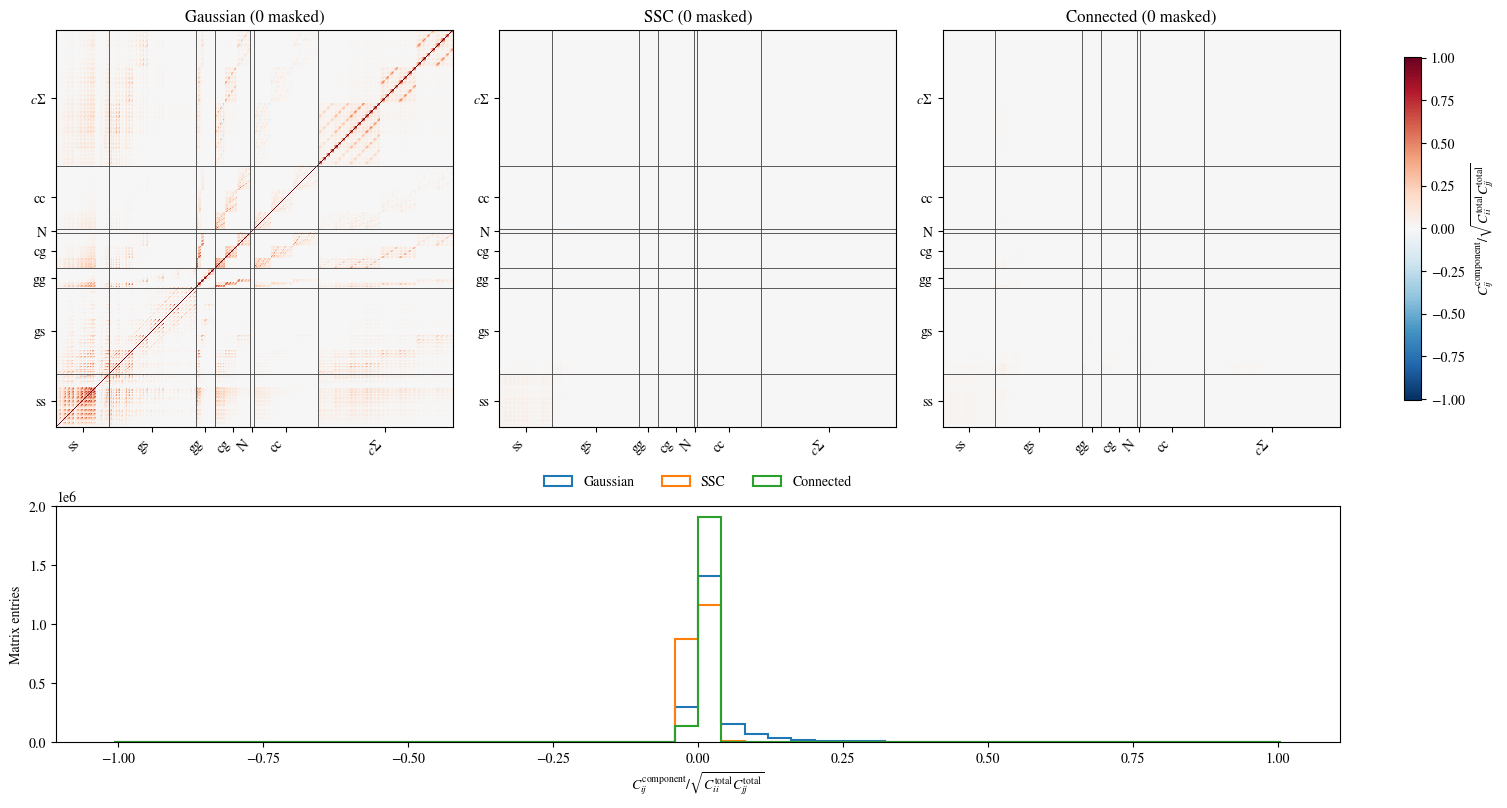

total positive definite: True minimum correlation eigenvalue: 0.001756175393844747


supplied positive definite: True minimum correlation eigenvalue: 0.0016256760086894903


In [9]:
supplied = read_likelihood_covariance(dataset=dataset)
block_sizes = [400, 480, 120, 240, 12, 600, 960]
block_labels = ['ss', 'gs', 'gg', 'cg', 'N', 'cc', '$c\\Sigma$']
selected = select_likelihood_entries(
    forecast=forecast,
    supplied=supplied,
    block_sizes=block_sizes,
    block_labels=block_labels,
)
print("Supplied file size:", supplied["file_size"])
print("Retained comparison size:", len(selected["indices"]))
print("Mask:", Path(supplied["mask_file"]).name)

pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["supplied"],
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    labels=("Computed forecast", "Supplied likelihood"),
)
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="diagonal",
)

# Positivity of both selected totals, from their correlation eigenvalues.
for label in ("total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    print(label, "positive definite:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

## What `select_likelihood_entries` kept

`select_likelihood_entries` applies one mask to every matrix and records, for each retained entry, its position in the uncut 2,812-entry vector (`selected["indices"]`). The next cell lists how many entries of each probe the 6×2pt + N mask keeps, confirms that no defined Y null row survives (the function raises an error otherwise), and uses the original positions to find the 12 counts inside the 1,429-entry selection. It then compares the count standard deviations of the two matrices. Both model the counts as Poisson noise plus the variance from long-wavelength density modes, but with different models and cosmologies (the supplied file uses the data-vector model at the Table I point), so a ratio away from one measures model differences, not numerical error.

In [10]:
# zip pairs each block length with its label, in data-vector order.
start = 0
for size, label in zip(block_sizes, block_labels):
    kept = np.count_nonzero(supplied["mask"][start:start + size])
    print(f"{label:>10}: {size:4d} entries, {kept:4d} kept by the likelihood mask")
    start += size
null_rows = forecast["cluster_lensing_positions"][:, -1]
print("Y null rows kept:", np.count_nonzero(np.isin(null_rows, selected["indices"])))

# np.isin finds the 12 count positions among the retained original indices.
count_rows = np.flatnonzero(np.isin(selected["indices"], forecast["count_positions"]))
variance_ratio = (np.diag(selected["total"])[count_rows]
                  / np.diag(selected["supplied"])[count_rows])
print("Count sigma, forecast/supplied:", np.round(np.sqrt(variance_ratio), decimals=3))

        ss:  400 entries,  190 kept by the likelihood mask
        gs:  480 entries,  312 kept by the likelihood mask
        gg:  120 entries,   69 kept by the likelihood mask
        cg:  240 entries,  128 kept by the likelihood mask
         N:   12 entries,   12 kept by the likelihood mask
        cc:  600 entries,  230 kept by the likelihood mask
 $c\Sigma$:  960 entries,  488 kept by the likelihood mask
Y null rows kept: 0
Count sigma, forecast/supplied: [0.933 0.949 0.973 0.965 0.899 0.928 0.965 0.96  0.876 0.916 0.963 0.962]


## Check changes with accuracy boost

With two or more boosts, the next cell compares the *computed* matrices after the same likelihood cuts. The highest tested boost is a comparison reference. Generalized eigenvalues solve $C_bv=\lambda\,C_{\rm ref}v$, where $C_b$ is the matrix at boost $b$ and $C_{\rm ref}$ the matrix at the highest boost. They bound the variance ratio $v^{\mathsf T}C_bv/v^{\mathsf T}C_{\rm ref}v$ for every linear combination $v$ of the retained measurements. The reported maximum departure from one is a fraction; 0.01 means 1%.

The error-bar panel selects the first source auto-correlation, $\xi_+$ of source bin 1. It shows the percent change of $\sqrt{C_{ii}}$ relative to the highest boost. This illustrates why convergence needs more than diagonal agreement. Refine quadrature separately at fixed boost, and eventually check marginalized Fisher errors and Figure of Merit. No matrix here has its eigenvalues clipped or its diagonal repaired.

The split-triangle layout follows [Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568).
Component maps adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).

In [11]:
if len(boosts) == 1:
    print("Set boosts = [1, 2] above and rerun to compare numerical accuracy.")
else:
    for boost in boosts:
        current = select_likelihood_entries(
            forecast=results[native_space][boost],
            supplied=supplied,
            block_sizes=block_sizes,
            block_labels=block_labels,
        )
        change = cov.compare_covariances(
            matrix=current["total"], reference=selected["total"],
        )
        print(boost, "maximum fractional variance change:",
              change["maximum_fractional_variance_change"])

    # The first observable is the first source auto-correlation, with
    # all its angular bins or Fourier bands consecutive in the full vector.
    nbin = 20
    reference = forecast["total"][:nbin, :nbin]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {boosts[-1]}"] = (
            results[native_space][boost]["total"][:nbin, :nbin]
        )
    # Geometric-mean centers of the logarithmic angular bins, in arcmin.
    coordinate = np.sqrt(settings["theta_edges_arcmin"][:-1]*settings["theta_edges_arcmin"][1:])
    pcov.plot_covariance_diagonal(
        theta_arcmin=coordinate,
        covariances=curves,
        panel_labels=['ss'],
        covariance_ref=reference,
        coordinate_label='$\\ell$' if native_space == "fourier" else '$\\theta\\;[\\mathrm{arcmin}]$',
    )

Set boosts = [1, 2] above and rerun to compare numerical accuracy.


## Inspect the C++ notebook interface

The compiled notebook wrappers are thin C++ functions written with Armadillo, a linear-algebra library whose vectors, matrices and cubes (three-dimensional arrays) carry named physical axes. pybind11 exposes them to Python, and CARMA converts NumPy inputs into owned Armadillo arrays; these copies are intentional, so a wrapper never modifies the caller's arrays. Whole Gaussian matrices and individual projection, halo and response components are available for independent experiments; production runs use the direct `ci.covariance` bindings of the command-line runner instead. The help text gives dimensions and units.

In [12]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)

Help on built-in function covariance_gaussian_fourier in module cosmolike_des_cluster_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: object, noise: object, pairs: object, operators: object, ell_min: int, area_sr: float) -> Numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.
    
    Returns an owned symmetric [nobservable*nband,nobservable*nband] matrix,
    with ban

## Save the calculation

The archives retain each physical component, the ordering arrays (including `count_positions`, `cluster_lensing_positions` and `valid_indices`), the physical assumptions with the omitted terms, and the resolved accuracy settings; `settings_json` stores the settings as text, so the archive loads without pickle. The separate likelihood-selection archive contains the compact matrices, original entry indices and the supplied total used in the plot. Only files in `covariance/` are written; the supplied files in `data/` remain unchanged. Running this cell again replaces the computed archives.

In [13]:
for space in spaces:
    save_forecast(
        result=results[space][boosts[-1]],
        filename=project/"covariance"/f"forecast_cluster.npz",
    )
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
np.savez(
    file=project/"covariance/forecast_likelihood_selection.npz",
    **selected,
    dataset=str(dataset.relative_to(project)),
    accuracy_boost=boosts[-1],
)
print("Saved covariance components and likelihood selection.")

Saved covariance components and likelihood selection.


## Optional galaxy/shear Fourier companion

This cell demonstrates the ordinary three-probe Fourier API with the same six lens and four source catalogs. It is **not** a cluster Fourier covariance: counts, cluster clustering and cluster lensing are absent. Set the flag to `True` to run it after the joint calculation. Its initialization replaces C state, so restart this notebook before recomputing the joint forecast.

The Fourier measurement has one row per measured field pair (E modes for shear), with integer multipoles weighted by their number of modes, $2\ell+1$, inside each of 15 bands between $\ell=30$ and 4000. A Fourier likelihood that evaluates its mean spectrum at logarithmic band centers differs from this band average, so the companion is an analogous bandpower calculation.

In [14]:
run_galaxy_companion = False
if run_galaxy_companion:
    import des_cluster_covariance as galaxy_survey
    from cosmolike_notebook_utils.covariance.forecast import (
        save_forecast as save_galaxy_forecast,
    )

    galaxy_settings = galaxy_survey.configuration(accuracy_boost=1)
    galaxy_survey.initialize(interface=ci, settings=galaxy_settings)
    ci.set_omp_threads(n=8)
    fourier = galaxy_survey.compute(
        interface=ci, settings=galaxy_settings, space="fourier", progress=progress,
    )
    pcov.plot_correlation(covariance=fourier["total"])
    save_galaxy_forecast(
        result=fourier, filename=project/"covariance/forecast_fourier.npz",
    )